<a href="https://www.kaggle.com/code/lalit7881/india-job-market-salary-trends-2026?scriptVersionId=301110166" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amar5693/india-job-market-and-salary-trends-2026/India_Job_Market_Salary_Trends_2026_CLEAN.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/amar5693/india-job-market-and-salary-trends-2026/India_Job_Market_Salary_Trends_2026_CLEAN.csv")

In [3]:
df.head()

,job_id,job_title,company_name,location,experience_required_years,skills,salary_min_inr,salary_max_inr,employment_type,remote_option
0,1,Data Analyst,Flipkart,Noida,3,"Kubernetes, Docker, Tableau",735003,1098465,Internship,Hybrid
1,2,ML Engineer,Infosys,Kolkata,3,"Python, React, Tableau",905315,1047637,Internship,Hybrid
2,3,ML Engineer,Cognizant,Hyderabad,11,"Node.js, Machine Learning, SQL",1733025,1964890,Internship,Remote
3,4,Backend Developer,Flipkart,Chennai,4,"Python, Machine Learning, React",801572,1141406,Contract,Hybrid
4,5,Data Analyst,Cognizant,Kolkata,15,"Power BI, Docker, Azure",818144,1208834,Contract,Remote


In [4]:
df.tail()

,job_id,job_title,company_name,location,experience_required_years,skills,salary_min_inr,salary_max_inr,employment_type,remote_option
9995,9996,DevOps Engineer,TCS,Chennai,8,"SQL, Node.js, Azure",1040221,1158068,Internship,Hybrid
9996,9997,Frontend Developer,Wipro,Chennai,3,"Node.js, Kubernetes, Java",973031,1334088,Contract,Hybrid
9997,9998,Backend Developer,Wipro,Kolkata,10,"Tableau, Docker, Java",1131348,1404597,Internship,Remote
9998,9999,Cybersecurity Analyst,Wipro,Bangalore,10,"Node.js, AWS, Power BI",995417,1391367,Full-time,Remote
9999,10000,Data Scientist,Tech Mahindra,Delhi NCR,8,"Machine Learning, Azure, Power BI",1754336,2130371,Contract,Hybrid


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   job_id                     10000 non-null  int64 
 1   job_title                  10000 non-null  object
 2   company_name               10000 non-null  object
 3   location                   10000 non-null  object
 4   experience_required_years  10000 non-null  int64 
 5   skills                     10000 non-null  object
 6   salary_min_inr             10000 non-null  int64 
 7   salary_max_inr             10000 non-null  int64 
 8   employment_type            10000 non-null  object
 9   remote_option              10000 non-null  object
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [6]:
df.describe()

,job_id,experience_required_years,salary_min_inr,salary_max_inr
count,10000.00000,10000.000000,1.000000e+04,1.000000e+04
mean,5000.50000,7.489300,1.146712e+06,1.395675e+06
std,2886.89568,4.596346,4.310013e+05,4.415012e+05
min,1.00000,0.000000,4.002240e+05,5.179770e+05
25%,2500.75000,4.000000,8.213712e+05,1.058016e+06
50%,5000.50000,7.000000,1.082927e+06,1.337484e+06
75%,7500.25000,11.000000,1.429934e+06,1.680679e+06
max,10000.00000,15.000000,2.399534e+06,2.790285e+06


In [7]:
df.isnull().sum()

job_id                       0
job_title                    0
company_name                 0
location                     0
experience_required_years    0
skills                       0
salary_min_inr               0
salary_max_inr               0
employment_type              0
remote_option                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

job_id                        int64
job_title                    object
company_name                 object
location                     object
experience_required_years     int64
skills                       object
salary_min_inr                int64
salary_max_inr                int64
employment_type              object
remote_option                object
dtype: object

In [10]:
df.shape

(10000, 10)

In [11]:
df.nunique()

job_id                       10000
job_title                       10
company_name                    10
location                         8
experience_required_years       16
skills                        1320
salary_min_inr                9966
salary_max_inr                9969
employment_type                  3
remote_option                    3
dtype: int64

In [12]:
df.columns

Index(['job_id', 'job_title', 'company_name', 'location',
       'experience_required_years', 'skills', 'salary_min_inr',
       'salary_max_inr', 'employment_type', 'remote_option'],
      dtype='object')

## EDA

In [13]:
sns.set(style="whitegrid")

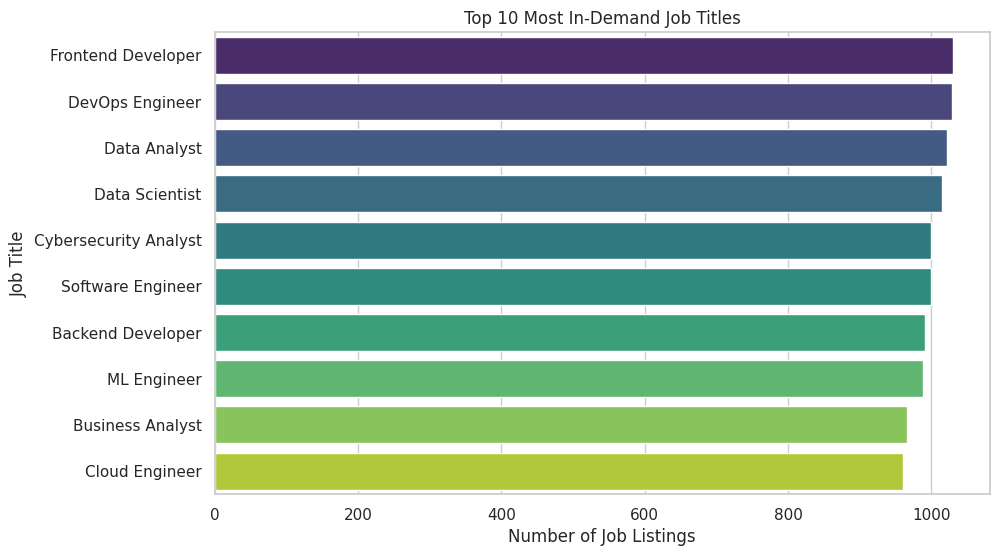

In [14]:
plt.figure(figsize=(10,6))
top_jobs = df['job_title'].value_counts().head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')
plt.title("Top 10 Most In-Demand Job Titles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Job Title")
plt.show()

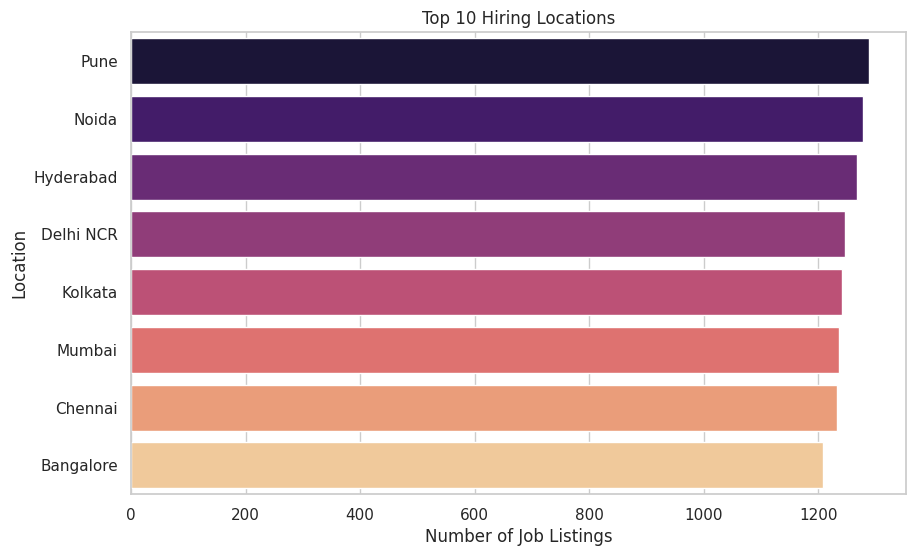

In [15]:
plt.figure(figsize=(10,6))
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')
plt.title("Top 10 Hiring Locations")
plt.xlabel("Number of Job Listings")
plt.ylabel("Location")
plt.show()

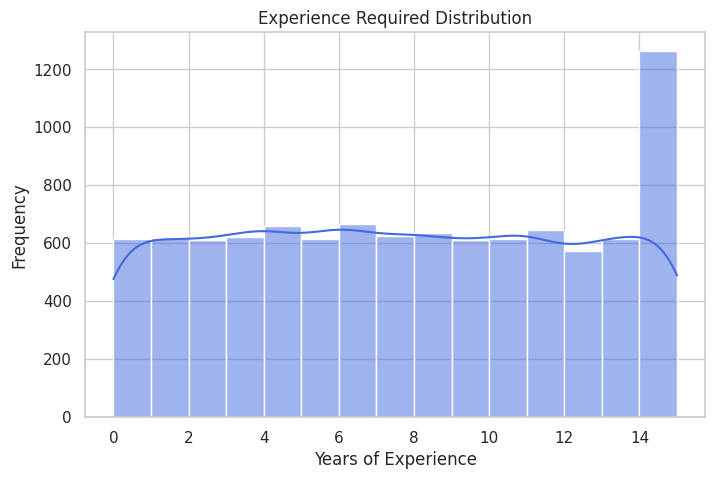

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['experience_required_years'], bins=15, kde=True, color='royalblue')
plt.title("Experience Required Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Frequency")
plt.show()

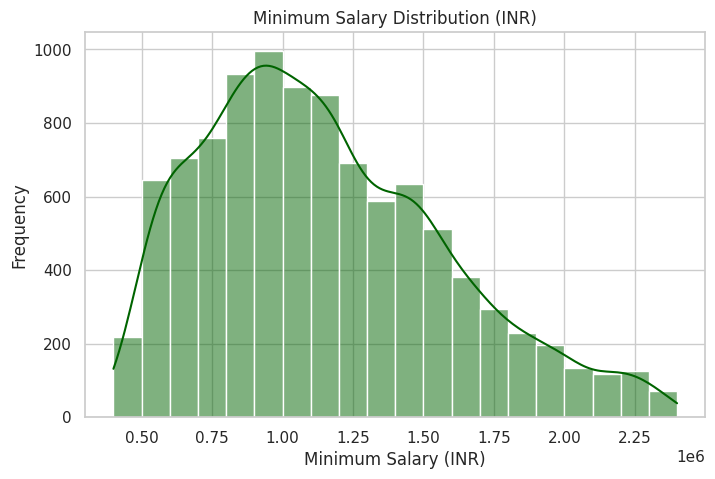

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_min_inr'], bins=20, kde=True, color='darkgreen')
plt.title("Minimum Salary Distribution (INR)")
plt.xlabel("Minimum Salary (INR)")
plt.ylabel("Frequency")
plt.show()

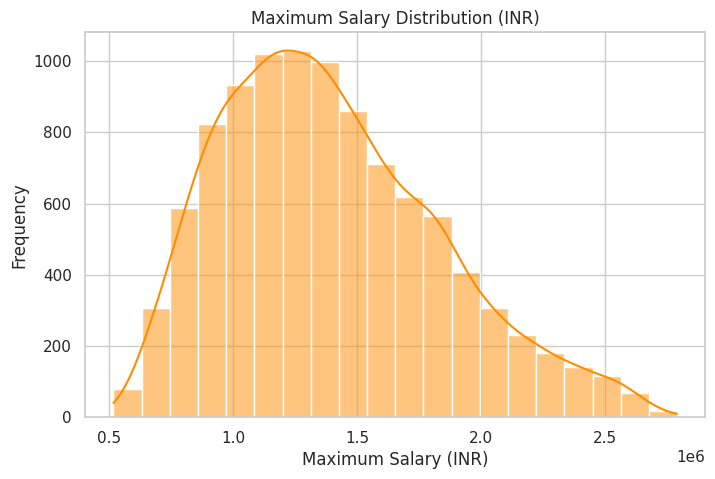

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_max_inr'], bins=20, kde=True, color='darkorange')
plt.title("Maximum Salary Distribution (INR)")
plt.xlabel("Maximum Salary (INR)")
plt.ylabel("Frequency")
plt.show()

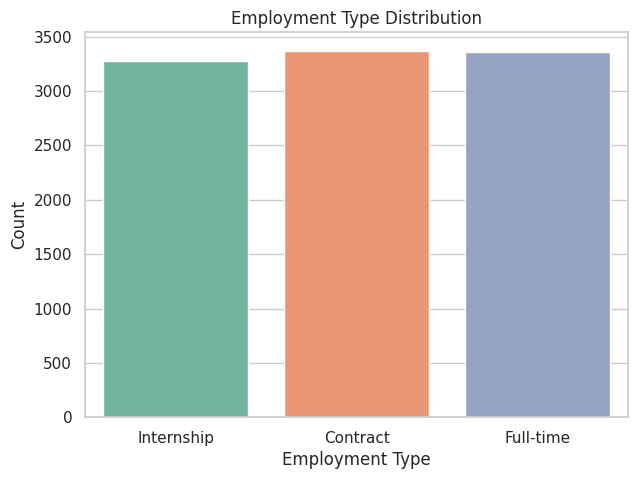

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(x='employment_type', data=df, palette='Set2')
plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.show()

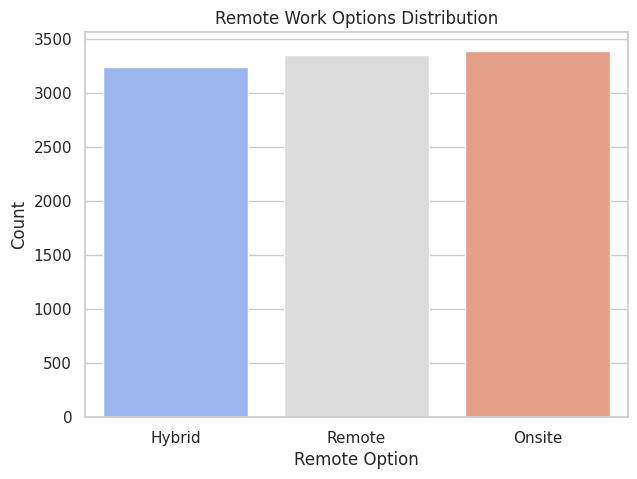

In [20]:
plt.figure(figsize=(7,5))
sns.countplot(x='remote_option', data=df, palette='coolwarm')
plt.title("Remote Work Options Distribution")
plt.xlabel("Remote Option")
plt.ylabel("Count")
plt.show()

In [21]:
df['avg_salary'] = (df['salary_min_inr'] + df['salary_max_inr']) / 2

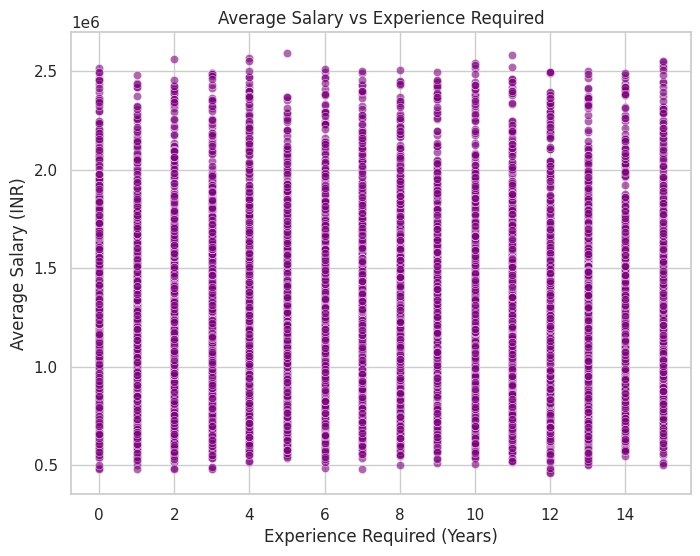

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='experience_required_years', 
                y='avg_salary', 
                data=df, 
                color='purple', 
                alpha=0.6)

plt.title("Average Salary vs Experience Required")
plt.xlabel("Experience Required (Years)")
plt.ylabel("Average Salary (INR)")
plt.show()

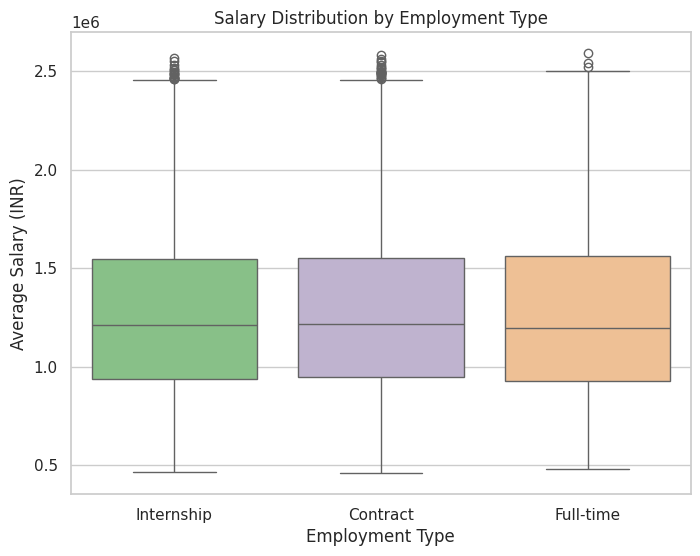

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(x='employment_type', y='avg_salary', data=df, palette='Accent')
plt.title("Salary Distribution by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Average Salary (INR)")
plt.show()

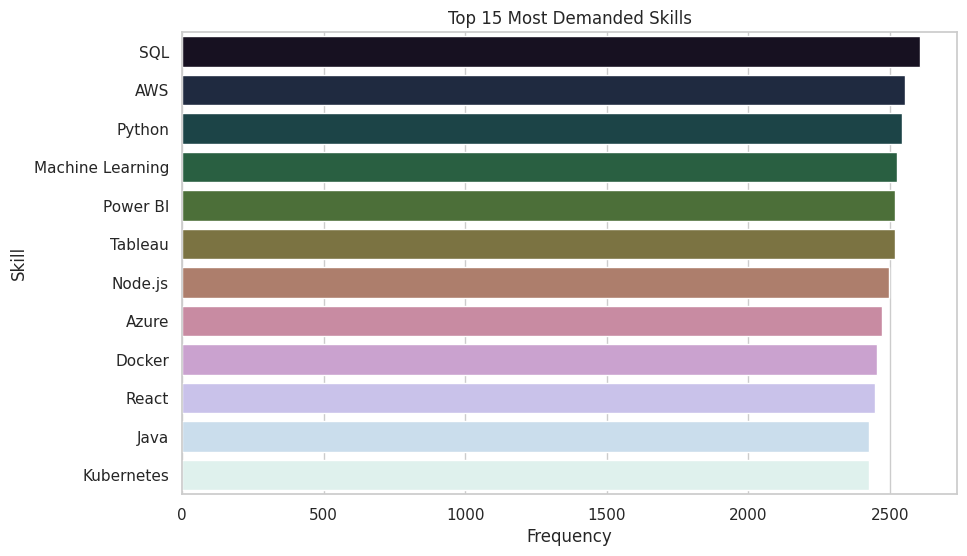

In [24]:
from collections import Counter

all_skills = df['skills'].dropna().str.split(',').sum()
skill_counts = Counter([skill.strip() for skill in all_skills])

top_skills = pd.DataFrame(skill_counts.most_common(15), columns=['Skill', 'Count'])

plt.figure(figsize=(10,6))
sns.barplot(x='Count', y='Skill', data=top_skills, palette='cubehelix')
plt.title("Top 15 Most Demanded Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.show()

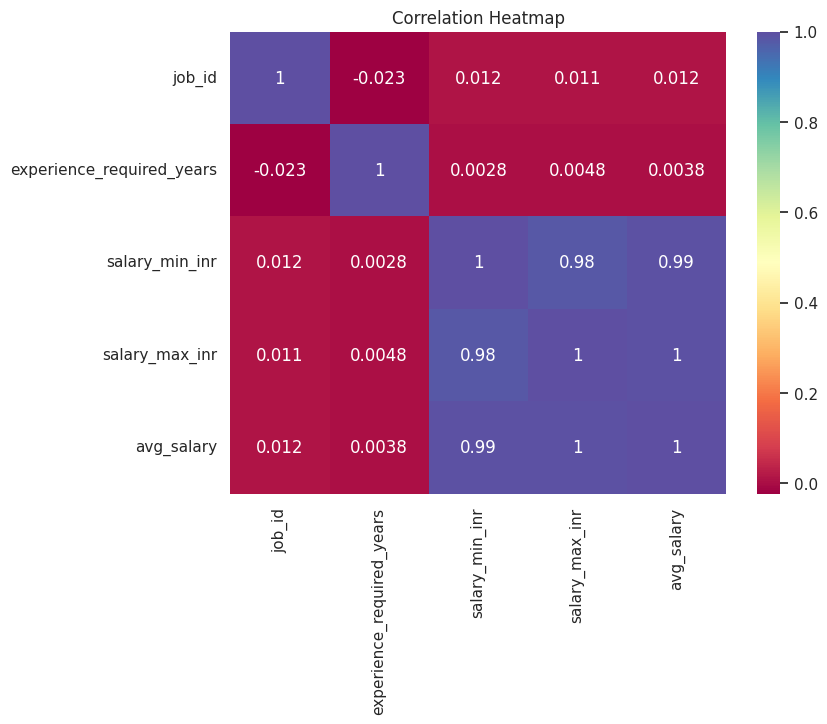

In [25]:
plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Spectral')
plt.title("Correlation Heatmap")
plt.show()

## Feature engg

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [27]:
df['avg_salary'] = (df['salary_min_inr'] + df['salary_max_inr']) / 2

# Drop unnecessary columns
df_model = df.drop(columns=['job_id'])

In [28]:
le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))


In [29]:
X = df_model.drop('remote_option', axis=1)
y = df_model['remote_option']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

Model: Logistic Regression
Accuracy: 34.85%

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.05      0.09       649
           1       0.36      0.56      0.44       679
           2       0.34      0.42      0.38       672

    accuracy                           0.35      2000
   macro avg       0.34      0.34      0.30      2000
weighted avg       0.34      0.35      0.30      2000



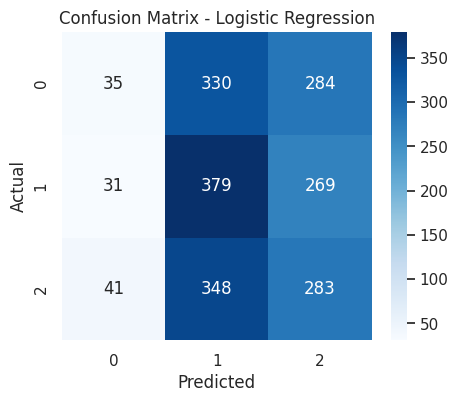

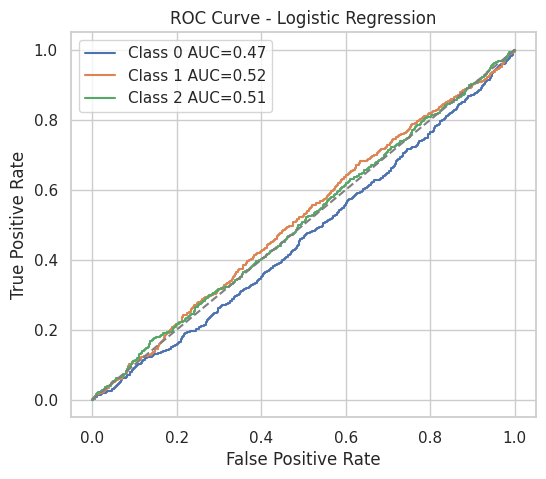

Model: Random Forest
Accuracy: 33.85%

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.33      0.34       649
           1       0.32      0.34      0.33       679
           2       0.35      0.34      0.35       672

    accuracy                           0.34      2000
   macro avg       0.34      0.34      0.34      2000
weighted avg       0.34      0.34      0.34      2000



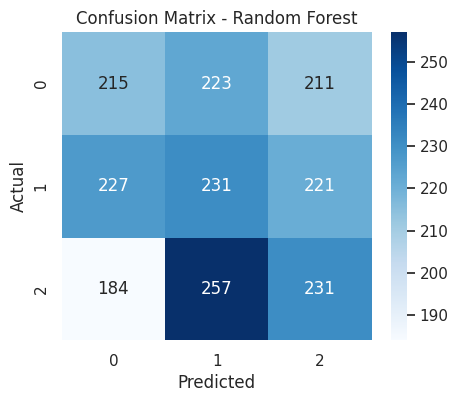

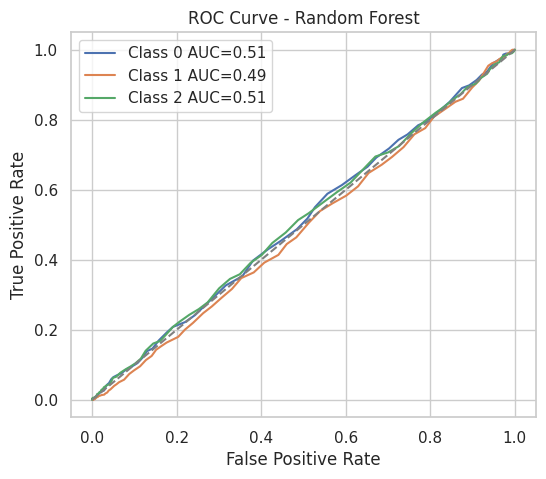

Model: Decision Tree
Accuracy: 31.40%

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.31      0.31       649
           1       0.31      0.32      0.31       679
           2       0.32      0.32      0.32       672

    accuracy                           0.31      2000
   macro avg       0.31      0.31      0.31      2000
weighted avg       0.31      0.31      0.31      2000



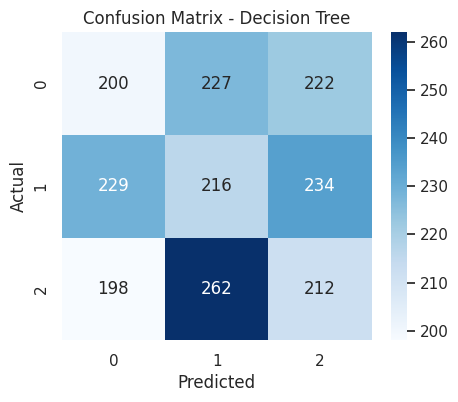

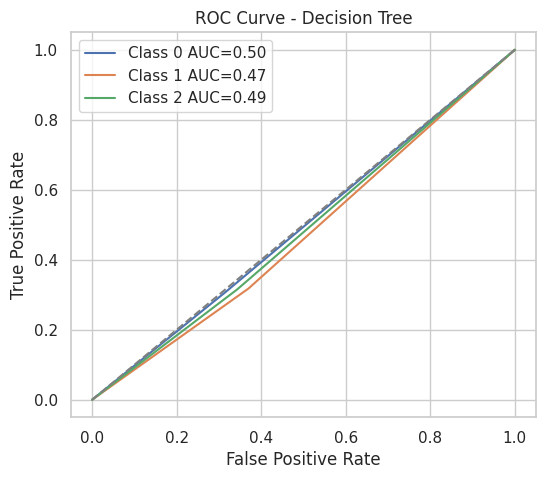

Model: SVM
Accuracy: 34.65%

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.24      0.28       649
           1       0.35      0.42      0.38       679
           2       0.35      0.37      0.36       672

    accuracy                           0.35      2000
   macro avg       0.35      0.35      0.34      2000
weighted avg       0.35      0.35      0.34      2000



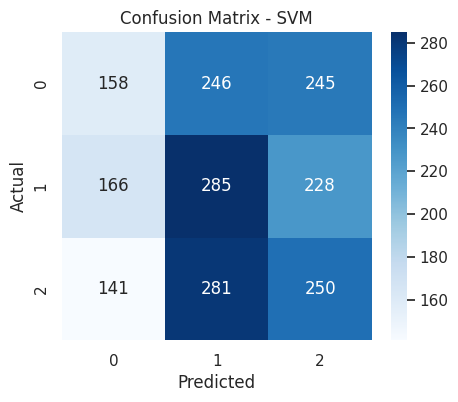

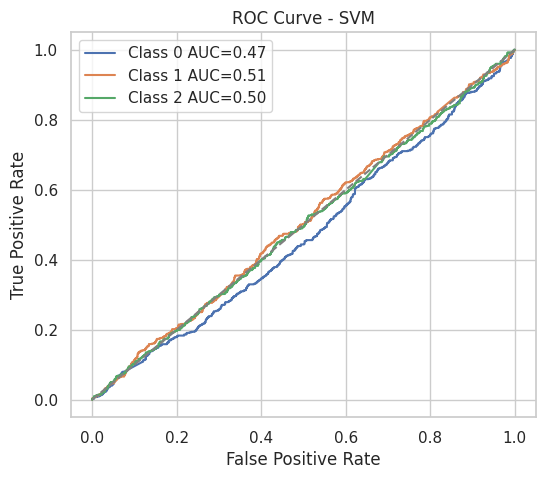

Model: Naive Bayes
Accuracy: 34.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.37      0.35       649
           1       0.36      0.36      0.36       679
           2       0.34      0.29      0.31       672

    accuracy                           0.34      2000
   macro avg       0.34      0.34      0.34      2000
weighted avg       0.34      0.34      0.34      2000



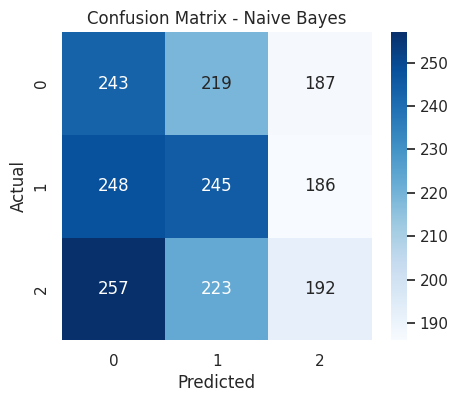

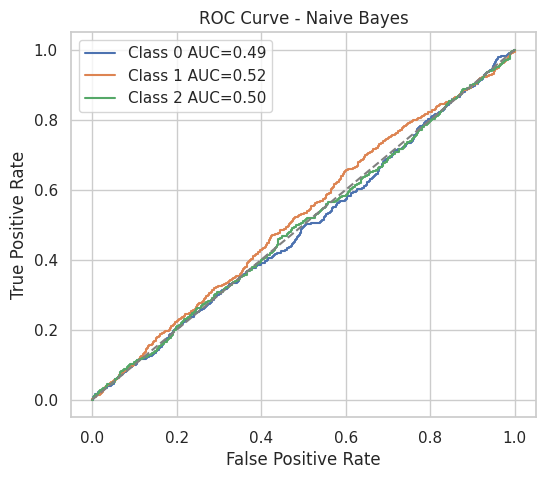

Model: KNN
Accuracy: 32.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.43      0.37       649
           1       0.32      0.34      0.33       679
           2       0.32      0.21      0.25       672

    accuracy                           0.32      2000
   macro avg       0.32      0.33      0.32      2000
weighted avg       0.32      0.32      0.32      2000



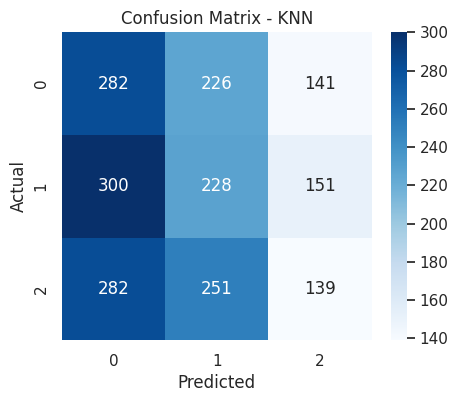

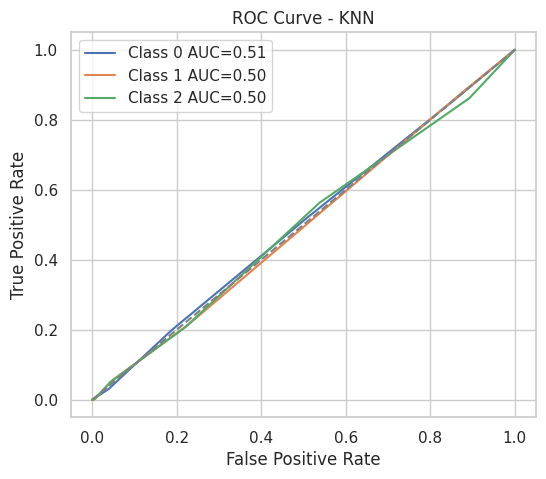

In [33]:
for name, model in models.items():
    
    print("="*70)
    print(f"Model: {name}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Accuracy: {acc:.2f}%")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=classes)
    n_classes = y_bin.shape[1]
    
    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    else:
        y_prob = model.decision_function(X_test)
        if y_prob.ndim == 1:
            y_prob = np.vstack([1 - y_prob, y_prob]).T
    
    plt.figure(figsize=(6,5))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_score = roc_auc_score(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} AUC={auc_score:.2f}")
    
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you..pls upvote!!!!1